### Imports ###

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.preprocessing import PowerTransformer
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
import optuna

### Data Preparation ###

In [2]:
# Load files
data_sensors = pd.read_csv("Indoor_Plant_Health_and_Growth_Factors.csv")
data_optimal = pd.read_csv("optimal_plant_conditions.csv")
light_values = pd.read_csv("light_intensity.csv")

# Merge files
data = pd.merge(
    data_sensors,
    data_optimal,
    left_on='Plant_ID',
    right_on='Plant_ID',
    how='left'
)

data["Light_Intensity"] = light_values["Lux_Value"]

data.head()

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,...,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux,Light_Intensity
0,Sansevieria cylindrica,17.39,17,8,Yellowing leaves,205,3,3h direct morning sun,21.7,77.5,...,Fungus gnats,Moderate,51.9,Clay,1,24,35,25,466,802
1,Aloe vera,9.84,31,9,NaN,191,1,3h direct morning sun,22.6,68.9,...,Aphids,Low,28.2,Loamy,2,24,35,25,850,970
2,Ficus lyrata,19.82,40,8,Brittle leaves,477,5,Indirect light all day,17.2,44.3,...,NaN,High,13.6,Sandy,1,24,50,45,850,306
3,Monstera deliciosa,37.08,11,1,New bud,207,1,Low light corner,25.0,72.2,...,Fungus gnats,Low,38.4,Sandy,4,25,70,65,650,121
4,Ficus lyrata,2.96,26,3,Wilting,465,2,Filtered sunlight through curtain,23.2,51.6,...,Fungus gnats,Low,37.9,Peaty,1,24,50,45,850,520


In [3]:
# Convert from milliliters to seconds for watering with the flow rate of 10ml/sec
data["Pump_time"] = data["Watering_Amount_ml"] / 10

# Drop irrelevant columns
data = data.drop(columns=["Fertilizer_Type", "Fertilizer_Amount_ml", "Pest_Presence", "Pest_Severity", "Soil_Type","Health_Score", "Height_cm", "Leaf_Count", "New_Growth_Count", "Health_Notes",  "Sunlight_Exposure", "Watering_Frequency_days", "Watering_Amount_ml"])
data.head()

,Plant_ID,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux,Light_Intensity,Pump_time
0,Sansevieria cylindrica,21.7,77.5,51.9,24,35,25,466,802,20.5
1,Aloe vera,22.6,68.9,28.2,24,35,25,850,970,19.1
2,Ficus lyrata,17.2,44.3,13.6,24,50,45,850,306,47.7
3,Monstera deliciosa,25.0,72.2,38.4,25,70,65,650,121,20.7
4,Ficus lyrata,23.2,51.6,37.9,24,50,45,850,520,46.5


### Clustering Ward's Method ###

In [4]:
optimal_features = [
    "Optimal_Room_Temperature_C",
    "Optimal_Humidity_%",
    "Optimal_Soil_Moisture_%",
    "Optimal_Light_Intensity_Lux"
]

scaler_optimal = StandardScaler()
data_optimal_scaled = data_optimal.copy()

optimal_X_scaled = pd.DataFrame(
    scaler_optimal.fit_transform(data_optimal_scaled[optimal_features]),
    columns=optimal_features,
    index=data_optimal_scaled.index
)

optimal_X_scaled

,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux
0,0.356034,0.210183,0.291077,-0.818911
1,0.356034,-1.700568,-1.763585,1.716416
2,1.542816,1.356633,0.975964,0.702286
3,-0.830747,0.592333,0.633521,0.195220
4,0.356034,1.356633,1.318408,-1.072443
5,-2.017529,-0.171968,-0.051367,-0.311845
6,1.542816,0.210183,0.291077,1.969949
7,0.356034,0.592333,0.633521,-0.058313
8,-0.830747,-1.318418,-1.421141,0.955818
9,0.356034,0.210183,0.291077,-0.565378


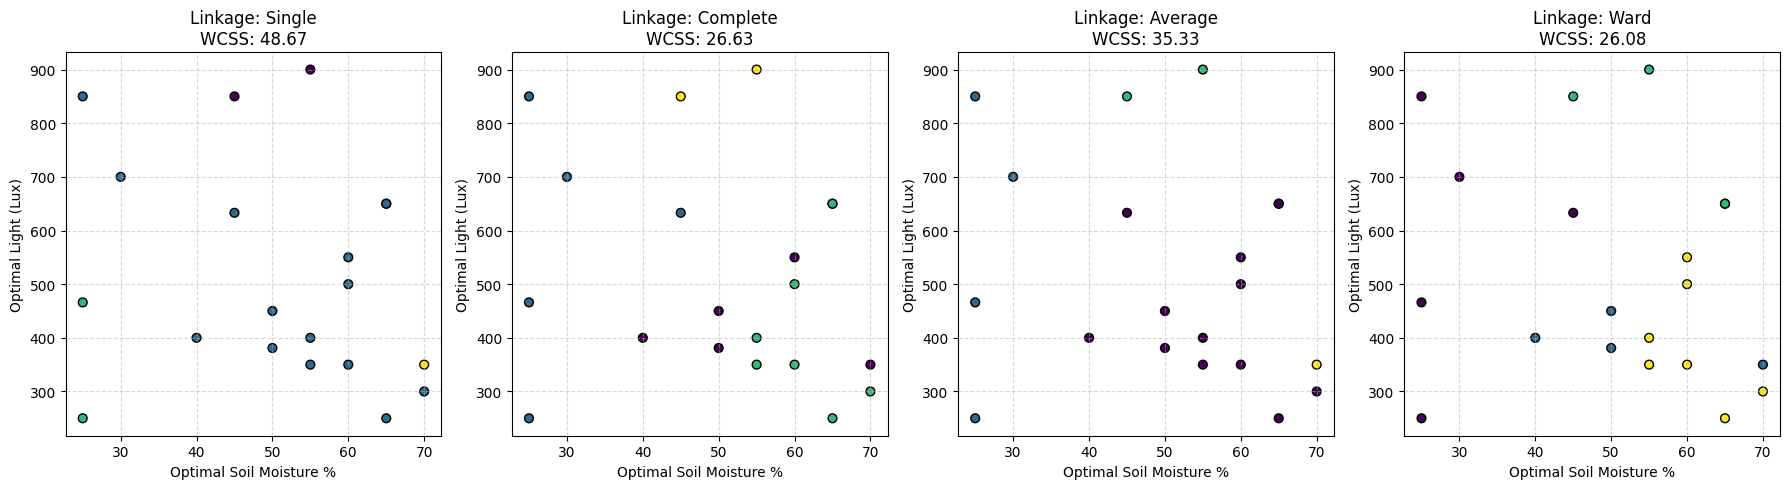

In [5]:
from sklearn.cluster import AgglomerativeClustering

# Different linkage methods (measure of distance between clusters)
methods = ['single', 'complete', 'average', 'ward']
plt.figure(figsize=(18, 5))
for i, link in enumerate(methods):
    model = AgglomerativeClustering(n_clusters=4, linkage=link)
    labels = model.fit_predict(optimal_X_scaled)
    # WCSS (within cluster sum of squares)
    wcss = 0
    for cluster_id in range(4):
        cluster_points = optimal_X_scaled[labels == cluster_id]
        centroid = cluster_points.mean(axis=0)
        wcss += np.sum((cluster_points - centroid) ** 2)

    plt.subplot(1, 4, i + 1)
    plt.scatter(data_optimal["Optimal_Soil_Moisture_%"], data_optimal["Optimal_Light_Intensity_Lux"], c=labels, cmap='viridis', s=40, edgecolors='k')
    plt.title(f"Linkage: {link.capitalize()}\nWCSS: {wcss:.2f}")
    plt.xlabel("Optimal Soil Moisture %")
    plt.ylabel("Optimal Light (Lux)")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

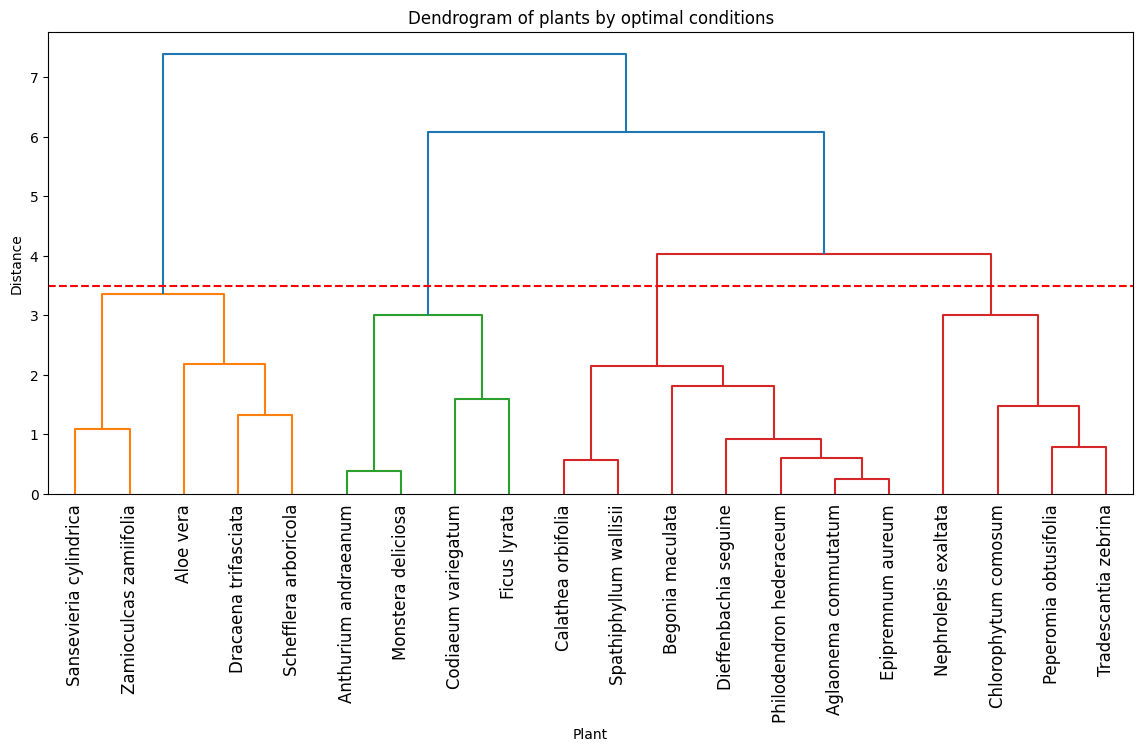

In [6]:
# Ward's method
Z = linkage(optimal_X_scaled, method='ward')
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=data_optimal['Plant_ID'].values, leaf_rotation=90)
plt.axhline(y=3.5, color='r', linestyle='--')
plt.title("Dendrogram of plants by optimal conditions")
plt.xlabel("Plant")
plt.ylabel("Distance")
plt.show()

In [7]:
K = 4
model = AgglomerativeClustering(n_clusters=K, linkage='ward').fit(optimal_X_scaled)
data_optimal['care_group'] = model.labels_

# Profile each cluster
profile = data_optimal.groupby('care_group')[optimal_features].mean().round(1)
profile['n_plants'] = data_optimal.groupby('care_group').size()
profile

,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux,n_plants
care_group,,,,,
0,23.6,39.0,30.0,579.8,5
1,22.5,58.8,52.5,395.2,4
2,24.8,63.8,57.5,762.5,4
3,23.9,65.7,60.7,385.7,7


In [8]:
# Plants per group
for g in sorted(data_optimal['care_group'].unique()):
    plants = data_optimal[data_optimal['care_group'] == g]['Plant_ID'].tolist()
    print(f"Group {g} ({len(plants)} plants): {plants}")

Group 0 (5 plants): ['Aloe vera', 'Dracaena trifasciata', 'Sansevieria cylindrica', 'Schefflera arboricola', 'Zamioculcas zamiifolia']
Group 1 (4 plants): ['Chlorophytum comosum', 'Nephrolepis exaltata', 'Peperomia obtusifolia', 'Tradescantia zebrina']
Group 2 (4 plants): ['Anthurium andraeanum', 'Codiaeum variegatum', 'Ficus lyrata', 'Monstera deliciosa']
Group 3 (7 plants): ['Aglaonema commutatum', 'Begonia maculata', 'Calathea orbifolia', 'Dieffenbachia seguine', 'Epipremnum aureum', 'Philodendron hederaceum', 'Spathiphyllum wallisii']


In [9]:
# Human-readable labels based on the profiles
group_labels = {
    0: "Succulent / dry-loving",     # warm, dry air, dry soil, bright
    1: "Cool-temperate moderate",    # cooler, moderate everything
    2: "Warm high-light",            # warmest, moderate humidity, brightest
    3: "Shade-tolerant tropical",    # warm, humid, low light
}
profile['label'] = profile.index.map(group_labels)
profile[['n_plants', 'label']]

,n_plants,label
care_group,,
0,5,Succulent / dry-loving
1,4,Cool-temperate moderate
2,4,Warm high-light
3,7,Shade-tolerant tropical


### Random Forest Classification after Clustering ###

### Feature Engineering for Classification ###

In [10]:
# Merge sensors with care_group
data = pd.merge(data_sensors, data_optimal, on='Plant_ID', how='left')
data["Light_Intensity"] = light_values["Lux_Value"]

# Drop irrelevant columns
data = data.drop(columns=["Fertilizer_Type", "Fertilizer_Amount_ml", "Pest_Presence",
                          "Pest_Severity", "Soil_Type", "Health_Score", "Height_cm",
                          "Leaf_Count", "New_Growth_Count", "Health_Notes", "Sunlight_Exposure", "Watering_Frequency_days"])

# Pump time
data["Pump_time"] = data["Watering_Amount_ml"] / 10
data = data.drop(columns=["Watering_Amount_ml"])

# Engineered features
data['soil_deficit']    = data['Optimal_Soil_Moisture_%'] - data['Soil_Moisture_%']
data['temp_deviation']  = data['Room_Temperature_C']      - data['Optimal_Room_Temperature_C']
data['air_hum_deficit'] = data['Optimal_Humidity_%']      - data['Humidity_%']
data['light_deviation'] = data['Light_Intensity']         - data['Optimal_Light_Intensity_Lux']
data['et_approx']       = (data['Room_Temperature_C'] * data['Light_Intensity']) / (data['Humidity_%'] + 1)

# Drop optimal columns and Plant_ID (so the model can't cheat)
data_model = data.drop(columns=["Optimal_Humidity_%", "Optimal_Room_Temperature_C",
                                "Optimal_Soil_Moisture_%", "Optimal_Light_Intensity_Lux",
                                "Plant_ID"])

data_model

,Room_Temperature_C,Humidity_%,Soil_Moisture_%,care_group,Light_Intensity,Pump_time,soil_deficit,temp_deviation,air_hum_deficit,light_deviation,et_approx
0,21.7,77.5,51.9,0,802,20.5,-26.9,-2.3,-42.5,336,221.699363
1,22.6,68.9,28.2,0,970,19.1,-3.2,-1.4,-33.9,120,313.619456
2,17.2,44.3,13.6,2,306,47.7,31.4,-6.8,5.7,-544,116.185430
3,25.0,72.2,38.4,2,121,20.7,26.6,0.0,-2.2,-529,41.325137
4,23.2,51.6,37.9,2,520,46.5,7.1,-0.8,-1.6,-330,229.353612
...,...,...,...,...,...,...,...,...,...,...,...
995,32.4,58.0,31.7,0,981,37.0,-6.7,8.4,-23.0,515,538.718644
996,24.3,39.4,32.9,0,957,9.1,12.1,1.3,10.6,324,575.621287
997,26.4,52.4,58.5,2,861,13.4,6.5,1.4,17.6,211,425.662921
998,18.7,60.1,24.8,3,786,44.2,30.2,-5.3,-0.1,386,240.559738


In [11]:
X = data_model.drop(columns=["care_group"])
y = data_model["care_group"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features: {list(X.columns)}")
print(f"Class distribution:\n{y.value_counts().sort_index()}")

Features: ['Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Light_Intensity', 'Pump_time', 'soil_deficit', 'temp_deviation', 'air_hum_deficit', 'light_deviation', 'et_approx']
Class distribution:
care_group
0    263
1    197
2    197
3    343
Name: count, dtype: int64


In [12]:
def objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators", 50, 500
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 2, 7
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "random_state": 42
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    return scores.mean()

In [13]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-05-15 14:17:25,326] A new study created in memory with name: no-name-cd0433e5-031b-4225-8aff-68ba50e4b867


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-15 14:17:26,516] Trial 0 finished with value: 0.5425000000000001 and parameters: {'n_estimators': 177, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5425000000000001.
[I 2026-05-15 14:17:28,850] Trial 1 finished with value: 0.66125 and parameters: {'n_estimators': 201, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 1 with value: 0.66125.
[I 2026-05-15 14:17:32,137] Trial 2 finished with value: 0.67 and parameters: {'n_estimators': 451, 'max_depth': 5, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 2 with value: 0.67.
[I 2026-05-15 14:17:34,862] Trial 3 finished with value: 0.69875 and parameters: {'n_estimators': 387, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.69875.
[I 2026-05-15 14:17:37,710] Trial 4 finished with value: 0.710000000000

In [14]:
print("Best parameters:")
print(study.best_params)

print(f"\nBest CV accuracy: {study.best_value:.3f}")

Best parameters:
{'n_estimators': 208, 'max_depth': 7, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2'}

Best CV accuracy: 0.727


In [15]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42
)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",208
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",13
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [16]:
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Train accuracy: 0.858
Test accuracy:  0.700


In [17]:
# Per-group classification report
preds = best_rf.predict(X_test)
print(classification_report(y_test, preds, digits=3))

              precision    recall  f1-score   support

           0      0.783     0.887     0.832        53
           1      0.800     0.103     0.182        39
           2      0.774     0.615     0.686        39
           3      0.625     0.942     0.751        69

    accuracy                          0.700       200
   macro avg      0.746     0.637     0.613       200
weighted avg      0.730     0.700     0.649       200



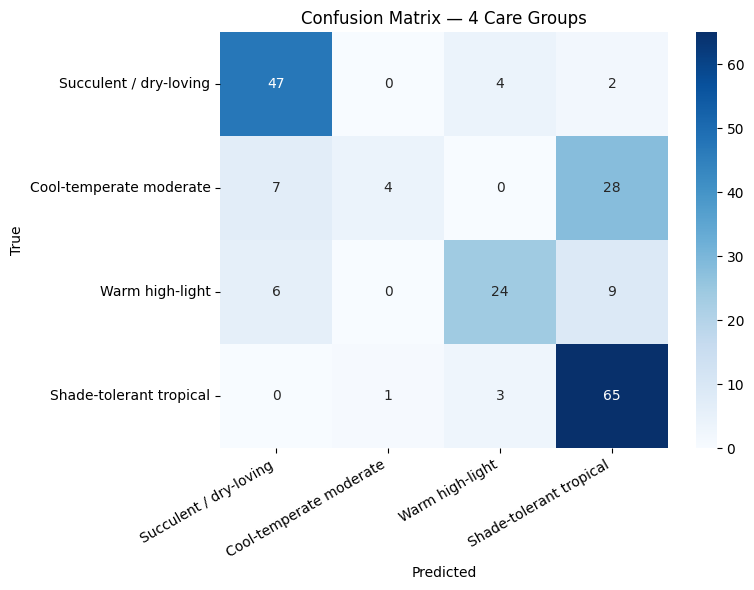

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, preds)
group_names = [group_labels[g] for g in sorted(group_labels.keys())]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=group_names, yticklabels=group_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {K} Care Groups')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

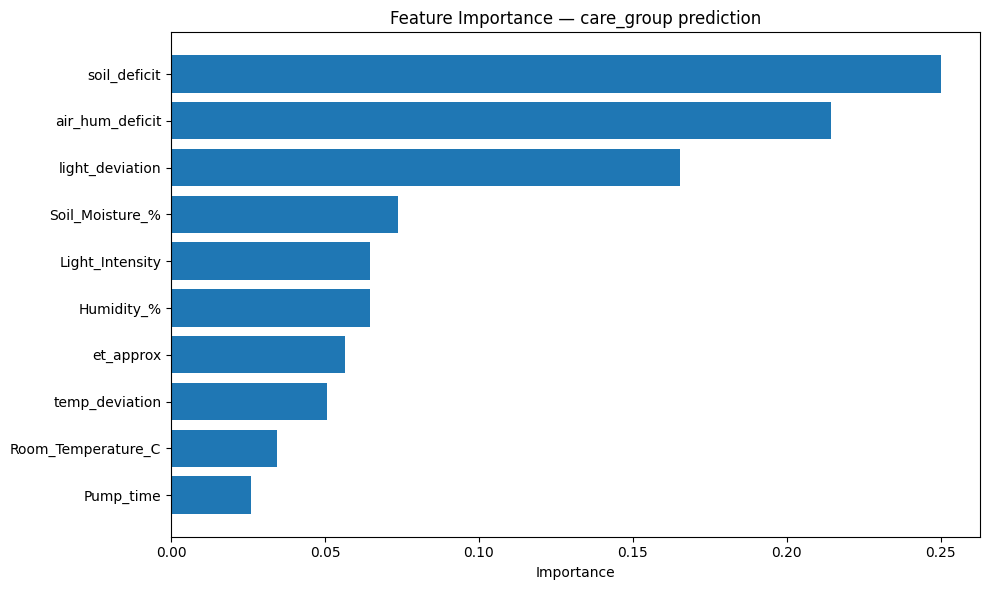

,Feature,Importance
5,soil_deficit,0.250209
7,air_hum_deficit,0.214303
8,light_deviation,0.165186
2,Soil_Moisture_%,0.073565
3,Light_Intensity,0.064740
1,Humidity_%,0.064600
9,et_approx,0.056612
6,temp_deviation,0.050496
0,Room_Temperature_C,0.034357
4,Pump_time,0.025931


In [20]:
# Feature importance
fi = pd.DataFrame({"Feature": X.columns, "Importance": best_rf.feature_importances_})
fi = fi.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fi["Feature"], fi["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance — care_group prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

fi